In [17]:
DATA_DIR = 'data/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE = DATA_DIR + 'sales_test.csv'

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Master
products = pd.read_csv(DATA_DIR + 'products.csv')
customers = pd.read_csv(DATA_DIR + 'customers.csv', parse_dates=['signup_date']) #
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date']) #
geography = pd.read_csv(DATA_DIR + 'geography.csv')
# Transaction
orders = pd.read_csv(DATA_DIR + 'orders.csv', parse_dates=['order_date']) #
order_items = pd.read_csv(DATA_DIR + 'order_items.csv', low_memory=False)
payments = pd.read_csv(DATA_DIR + 'payments.csv')
shipments = pd.read_csv(DATA_DIR + 'shipments.csv', parse_dates=['ship_date', 'delivery_date']) #
returns = pd.read_csv(DATA_DIR + 'returns.csv', parse_dates=['return_date']) #
reviews = pd.read_csv(DATA_DIR + 'reviews.csv', parse_dates=['review_date']) #
# Analytical
sales = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date']) #
# Operational
inventory = pd.read_csv(DATA_DIR + 'inventory.csv', parse_dates=['snapshot_date']) #
web_traffic = pd.read_csv(DATA_DIR + 'web_traffic.csv')

In [19]:
def quick_check(df, df_name):
    print(f"\n{'='*10} CHECKING TABLE: {df_name} {'='*10}")
    # Overall
    df.info()
    print(df.describe())

    # 1. Duplicates
    print(f"Duplicates: {df.duplicated().sum()} rows")

    # 2. Null values
    null_counts = df.isnull().sum()
    if null_counts.sum() > 0:
        print("Nulls found:\n", null_counts[null_counts > 0])
    else:
        print("No null values.")

    # 3. Shape
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")

quick_check(products, 'products')
quick_check(customers, 'customers')
quick_check(promotions, 'promotions')
quick_check(geography, 'geography')
quick_check(orders, 'orders')
quick_check(order_items, 'order_items')
quick_check(payments, 'payments')
quick_check(shipments, 'shipments')
quick_check(returns, 'returns')
quick_check(reviews, 'reviews')
quick_check(sales, 'sales')
quick_check(inventory, 'inventory')
quick_check(web_traffic, 'web_traffic')


========== CHECKING TABLE: products ==========
<class 'pandas.DataFrame'>
RangeIndex: 2412 entries, 0 to 2411
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2412 non-null   int64  
 1   product_name  2412 non-null   str    
 2   category      2412 non-null   str    
 3   segment       2412 non-null   str    
 4   size          2412 non-null   str    
 5   color         2412 non-null   str    
 6   price         2412 non-null   float64
 7   cogs          2412 non-null   float64
dtypes: float64(2), int64(1), str(5)
memory usage: 150.9 KB
        product_id         price          cogs
count  2412.000000   2412.000000   2412.000000
mean   1206.500000   4928.216231   3868.346732
std     696.428747   4776.737669   3878.584151
min       1.000000      9.056594      5.183829
25%     603.750000     59.444924     35.066367
50%    1206.500000   4399.605000   3184.934093
75%    1809.250000   7720.513784   586

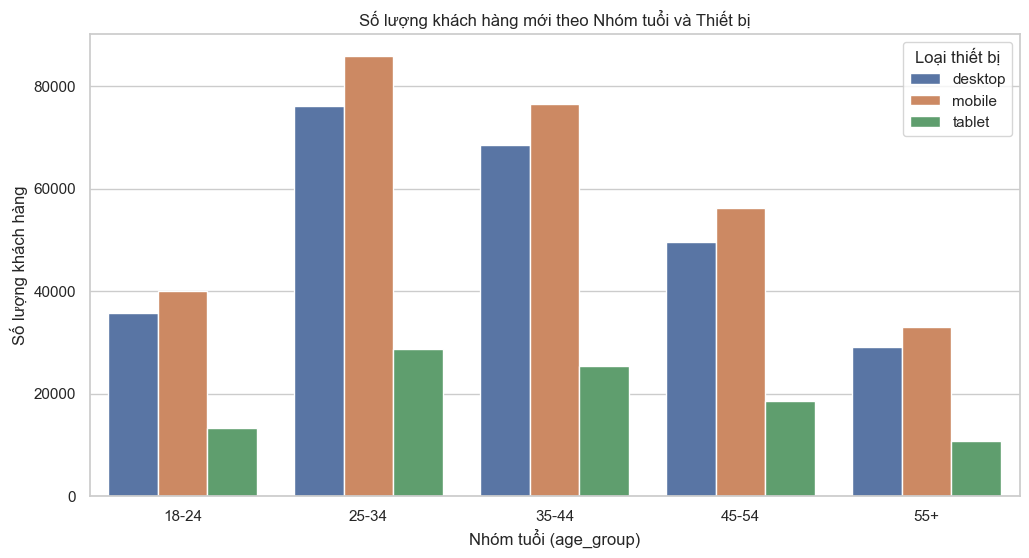

In [34]:
# Kết hợp dữ liệu Khách hàng và Đơn hàng
df_customer_orders = pd.merge(orders, customers, on='customer_id', how='left')

# Lọc các dòng có age_group không null để biểu đồ sạch hơn [cite: 166]
df_plot1 = df_customer_orders.dropna(subset=['age_group'])

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
sns.countplot(data=df_plot1, x='age_group', hue='device_type', 
              order=sorted(df_plot1['age_group'].unique()))

plt.title('Số lượng khách hàng mới theo Nhóm tuổi và Thiết bị')
plt.xlabel('Nhóm tuổi (age_group)')
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Loại thiết bị')
plt.show()


### 1. Phân tích tổng quan theo Nhóm tuổi
- Nhóm khách hàng chủ lực (25-44 tuổi): Đây là phân khúc đóng góp số lượng khách hàng mới cao nhất. Đặc biệt, nhóm 25-34 là nhóm dẫn đầu ở tất cả các loại thiết bị, cho thấy đây là đối tượng mục tiêu quan trọng nhất của doanh nghiệp.

- Nhóm trẻ (18-24) và Nhóm lớn tuổi (55+): Có số lượng khách hàng mới thấp hơn đáng kể so với các nhóm trung niên, cho thấy sản phẩm/dịch vụ có thể chưa thực sự thu hút hoặc chưa tiếp cận mạnh mẽ tới hai phân khúc đầu và cuối của tháp độ tuổi.

### 2. Phân tích theo Loại thiết bị (Device)
- Mobile (Điện thoại di động): Là thiết bị phổ biến nhất ở tất cả các nhóm tuổi. Đỉnh điểm là ở nhóm 25-34 với hơn 80.000 khách hàng mới. Điều này khẳng định chiến lược "Mobile-first" là bắt buộc.

- Desktop (Máy tính để bàn): Đứng vị trí thứ hai. Đáng chú ý, ở các nhóm tuổi từ 25 đến 54, khoảng cách giữa Desktop và Mobile không quá lớn so với nhóm trẻ (18-24). Điều này có thể gợi ý rằng khách hàng trung niên vẫn có thói quen sử dụng máy tính để thực hiện các giao dịch hoặc tìm kiếm dịch vụ.

- Tablet (Máy tính bảng): Luôn chiếm tỷ trọng thấp nhất ở mọi nhóm tuổi. Tuy nhiên, nhóm 25-34 và 35-44 vẫn có lượng sử dụng tablet cao hơn hẳn các nhóm còn lại.

### 3. Xu hướng phân bổ chi tiết theo từng nhóm tuổi
- Nhóm 18-24 tuổi: Đây là nhóm có sự chênh lệch rõ rệt nhất giữa các thiết bị. Lượng người dùng Mobile cao gấp khoảng 3 lần so với Tablet, cho thấy giới trẻ gần như chỉ tiếp cận dịch vụ qua điện thoại cá nhân.

- Nhóm 25-34 tuổi (Phân khúc trọng điểm): Đây là "đỉnh" của biểu đồ với số lượng khách hàng mới cao nhất ở tất cả các loại thiết bị. Đặc biệt, lượng người dùng Mobile vượt mốc 80.000, trong khi Desktop cũng đạt mức rất cao (hơn 75.000), chứng tỏ sự đa dạng trong cách tiếp cận của nhóm này.

- Nhóm 35-44 tuổi: Xu hướng tương tự như nhóm 25-34 nhưng với quy mô thấp hơn một chút. Tuy nhiên, lượng người dùng Tablet ở nhóm này vẫn duy trì ở mức khá tốt so với mặt bằng chung, cho thấy thói quen sử dụng thiết bị màn hình lớn vẫn tồn tại trong sinh hoạt hàng ngày.

- Nhóm 45-54 tuổi: Số lượng khách hàng bắt đầu giảm dần. Dù vậy, Mobile vẫn dẫn đầu với khoảng hơn 55.000 khách hàng mới, theo sau là Desktop với gần 50.000. Khoảng cách giữa hai thiết bị này khá hẹp, phản ánh thói quen làm việc trên máy tính vẫn rất phổ biến ở độ tuổi trung niên.

- Nhóm 55+ tuổi: Đây là phân khúc có số lượng khách hàng mới thấp nhất. Tỷ lệ sử dụng thiết bị giảm đều ở cả ba loại, với Mobile vẫn là kênh tiếp cận chính nhưng chỉ đạt mức hơn 30.000 khách hàng.

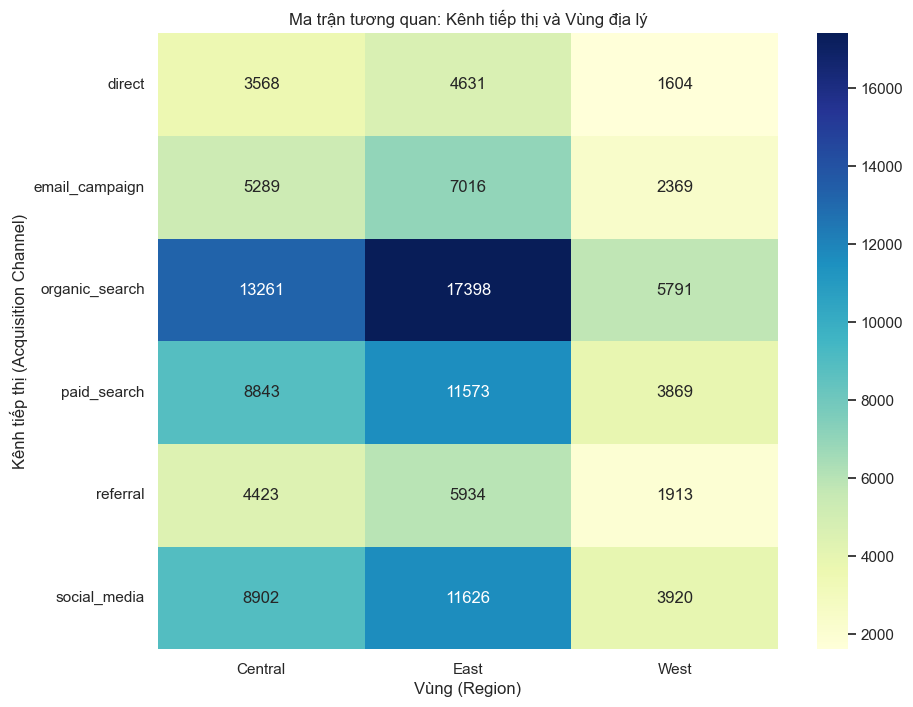

In [35]:
# Kết hợp Customers với Geography qua cột 'zip'
df_geo_customer = pd.merge(customers, geography, on='zip', how='left')

# Tạo bảng pivot tính số lượng khách hàng cho mỗi cặp (Kênh, Vùng)
heatmap_data = df_geo_customer.groupby(['acquisition_channel', 'region']).size().unstack(fill_value=0)

# Vẽ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Ma trận tương quan: Kênh tiếp thị và Vùng địa lý')
plt.xlabel('Vùng (Region)')
plt.ylabel('Kênh tiếp thị (Acquisition Channel)')
plt.show()

### 1. Phân tích Vùng địa lý (Region)
- Vùng East (Miền Đông): Đây là thị trường quan trọng nhất, chiếm ưu thế tuyệt đối ở tất cả các kênh tiếp thị. Mọi chỉ số tại đây đều cao hơn hẳn so với Central và West.

- Vùng Central (Miền Trung): Đứng vị trí thứ hai, đóng vai trò là thị trường tiềm năng duy trì sự ổn định.

- Vùng West (Miền Tây): Đây là vùng có hiệu suất thấp nhất. Các con số ở vùng này thường chỉ bằng khoảng 1/3 so với vùng East, cho thấy sự hiện diện của thương hiệu hoặc nhu cầu thị trường tại đây còn khá mỏng.

### 2. Phân tích Kênh tiếp thị (Acquisition Channel)
- Kênh dẫn đầu - Organic Search: Đây là "ngôi sao" của doanh nghiệp. Việc khách hàng tự tìm kiếm (tự nhiên) mang lại lượng truy cập/chuyển đổi lớn nhất, đặc biệt là tại vùng East (17.398). Điều này chứng tỏ hiệu quả SEO hoặc nhận diện thương hiệu tự nhiên đang làm rất tốt.

- Kênh quảng cáo trả phí - Paid Search & Social Media: Hai kênh này có hiệu suất tương đương nhau và giữ vai trò quan trọng thứ hai.

- Social Media nhỉnh hơn một chút so với Paid Search ở tất cả các vùng.

- Tại vùng East, Social Media đạt 11.626 trong khi Paid Search là 11.573.

- Các kênh bổ trợ - Email Campaign, Referral, Direct: Các kênh này đóng góp khiêm tốn hơn. Trong đó, Email Campaign tại vùng East (7.016) vẫn hiệu quả hơn hẳn so với việc khách hàng truy cập trực tiếp (Direct) hay qua giới thiệu (Referral).

### 3. Xu hướng phân bổ chi tiết
- Vùng East: Thể hiện sức mạnh áp đảo ở kênh Organic Search (17.398). Đây là nơi tập trung khách hàng chủ lực, phản ứng tốt với mọi chiến dịch marketing từ trả phí đến tự nhiên.

- Kênh Organic Search: Luôn đứng đầu bảng ở mọi vùng miền (Central: 13.261, West: 5.791). Điều này cho thấy khách hàng có xu hướng chủ động tìm kiếm sản phẩm/dịch vụ trên các công cụ tìm kiếm.

- Kênh Social Media: Hoạt động hiệu quả nhất ở vùng East và Central, cho thấy các nội dung trên mạng xã hội đang tiếp cận đúng đối tượng ở hai khu vực này.

- Kênh Direct & Referral: Có chỉ số thấp nhất, đặc biệt là tại vùng West (Direct: 1604, Referral: 1913). Điều này gợi ý rằng lòng trung thành thương hiệu hoặc mạng lưới giới thiệu tại miền Tây còn rất hạn chế.

Khoảng cách mua hàng trung bình: 285.6 ngày


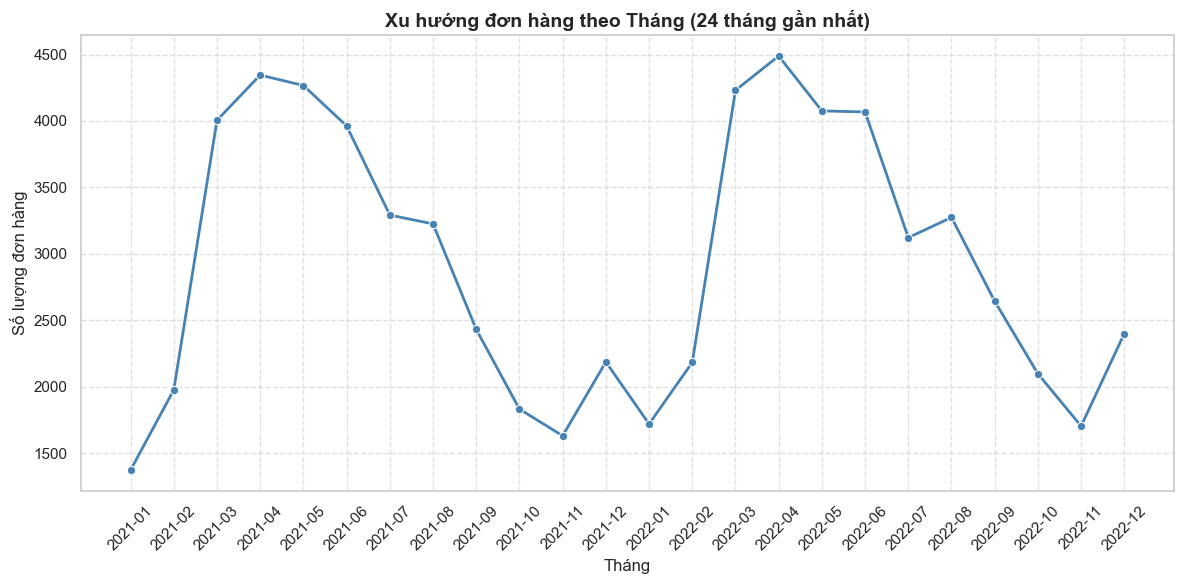

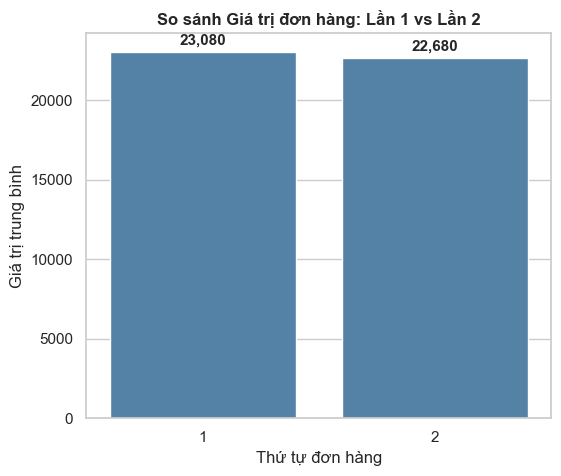

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. TÍNH KHOẢNG CÁCH GIỮA CÁC ĐƠN HÀNG (INTER-ORDER GAP)
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders = orders.sort_values(['customer_id', 'order_date'])

orders['prev_order_date'] = orders.groupby('customer_id')['order_date'].shift(1)
orders['inter_order_gap'] = (orders['order_date'] - orders['prev_order_date']).dt.days

re_orders = orders.dropna(subset=['inter_order_gap'])
print(f"Khoảng cách mua hàng trung bình: {re_orders['inter_order_gap'].mean():.1f} ngày")

# 2. CHUẨN BỊ DỮ LIỆU THEO THÁNG
orders['order_month'] = orders['order_date'].dt.to_period('M').astype(str)

# 3. PHÂN TÍCH NHỊP ĐIỆU MUA SẮM (CHỈ THEO THÁNG)
plt.figure(figsize=(12, 6))

# --- BIỂU ĐỒ 1: XU HƯỚNG THEO THÁNG ---
# Lấy 24 tháng gần nhất để biểu đồ rõ ràng
monthly_counts = orders['order_month'].value_counts().sort_index().tail(24) 

sns.lineplot(x=monthly_counts.index, y=monthly_counts.values, marker='o', color='steelblue', linewidth=2)
plt.title('Xu hướng đơn hàng theo Tháng (24 tháng gần nhất)', fontweight='bold', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Số lượng đơn hàng')
plt.xlabel('Tháng')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ 2: SO SÁNH GIÁ TRỊ ĐƠN HÀNG LẦN 1 VS LẦN 2 ---
order_val = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders['order_rank'] = orders.groupby('customer_id').cumcount() + 1
comparison_df = orders[orders['order_rank'].isin([1, 2])].merge(order_val, on='order_id')

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=comparison_df, x='order_rank', y='payment_value', color='steelblue', errorbar=None)

# Thêm số liệu trực tiếp trên đầu cột để dễ so sánh
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.title('So sánh Giá trị đơn hàng: Lần 1 vs Lần 2', fontweight='bold')
plt.xlabel('Thứ tự đơn hàng')
plt.ylabel('Giá trị trung bình')
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12568\694432721.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=15)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12568\694432721.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a.set_xticklabels(a.get_xticklabels(), rotation=15)


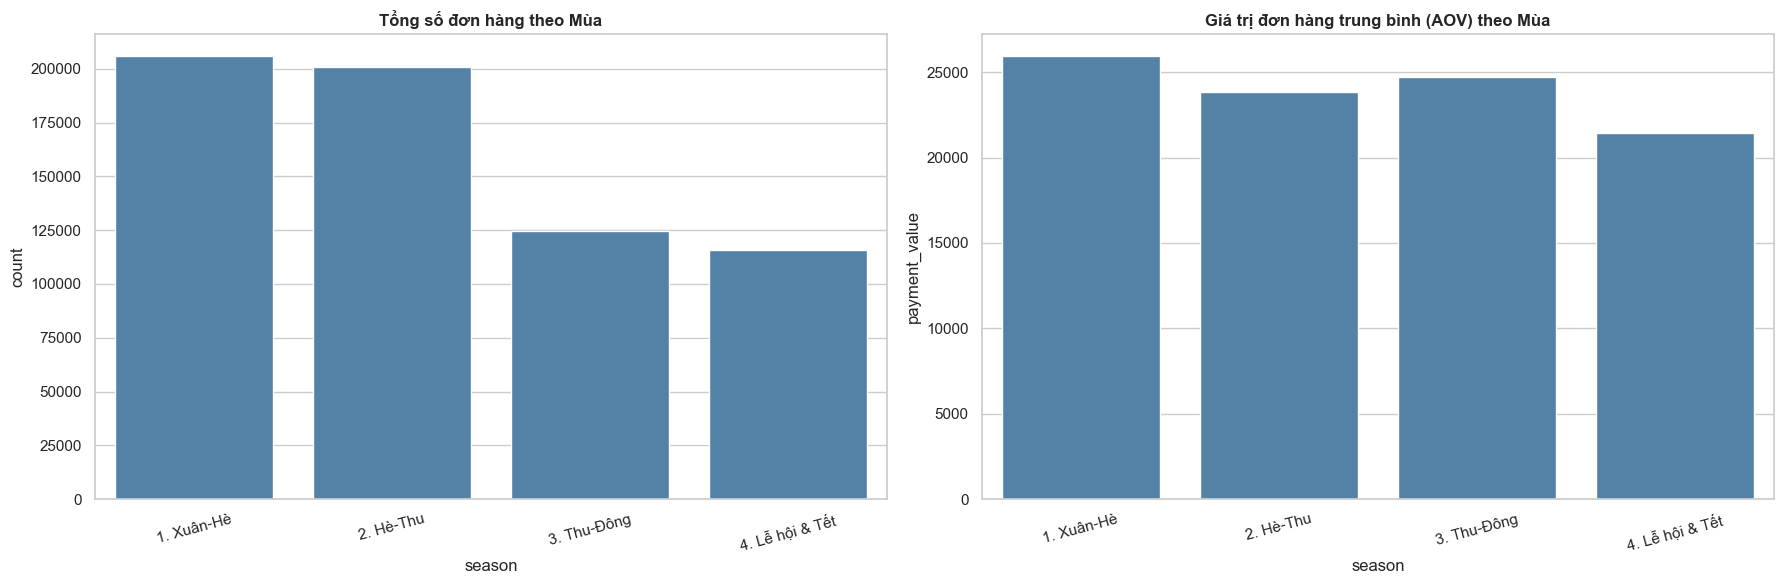

In [ ]:
# 1. Định nghĩa hàm phân loại mùa
def get_season(month):
    if month in [3, 4, 5]:
        return '1. Xuân-Hè'
    elif month in [6, 7, 8]:
        return '2. Hè-Thu'
    elif month in [9, 10, 11]:
        return '3. Thu-Đông'
    else:
        return '4. Lễ hội & Tết'

# 2. Xử lý dữ liệu
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['season'] = orders['month'].apply(get_season)

# 3. Tính toán doanh thu và sửa lỗi NaN
order_val = payments.groupby('order_id')['payment_value'].sum().reset_index()
orders_with_val = orders.merge(order_val, on='order_id', how='left')

# --- BƯỚC SỬA LỖI QUAN TRỌNG ---
# Loại bỏ các đơn hàng không có dữ liệu thanh toán để tránh lỗi vẽ biểu đồ
orders_with_val = orders_with_val.dropna(subset=['payment_value'])

# 4. Trực quan hóa
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Số lượng đơn hàng theo Mùa
sns.countplot(data=orders_with_val, x='season', ax=ax[0], color='steelblue', 
              order=sorted(orders_with_val['season'].unique()))
ax[0].set_title('Tổng số đơn hàng theo Mùa', fontweight='bold')

# Biểu đồ 2: Giá trị đơn hàng trung bình (AOV) theo Mùa
sns.barplot(data=orders_with_val, x='season', y='payment_value', ax=ax[1], color='steelblue', 
            errorbar=None, order=sorted(orders_with_val['season'].unique()))
ax[1].set_title('Giá trị đơn hàng trung bình (AOV) theo Mùa', fontweight='bold')

# Tối ưu hiển thị
for a in ax:
    a.set_xticklabels(a.get_xticklabels(), rotation=15)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

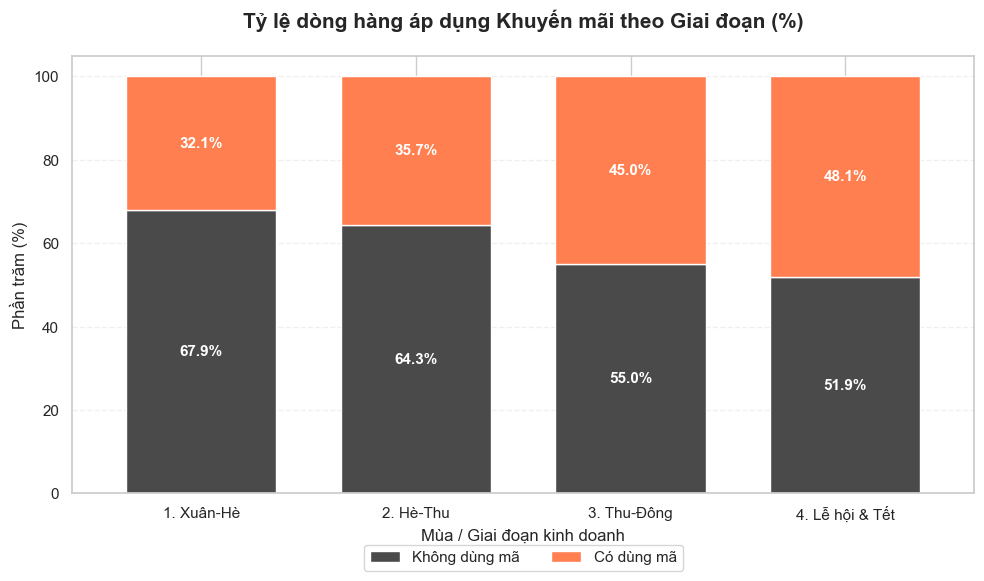

In [ ]:
# 1. Hàm phân loại mùa
def get_season(month):
    if month in [3, 4, 5]: return '1. Xuân-Hè'
    elif month in [6, 7, 8]: return '2. Hè-Thu'
    elif month in [9, 10, 11]: return '3. Thu-Đông'
    else: return '4. Lễ hội & Tết'

# 2. Xử lý dữ liệu
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['month'] = orders['order_date'].dt.month
orders['season'] = orders['month'].apply(get_season)

# Kết hợp dữ liệu: order_items chứa promo_id [cite: 56], orders chứa thời gian [cite: 51]
df_merged = order_items.merge(orders[['order_id', 'season']], on='order_id', how='left')

# Kiểm tra áp dụng khuyến mãi (bao gồm cả promo_id_2 cho các khuyến mãi cộng dồn) [cite: 56, 40]
df_merged['has_promo'] = df_merged['promo_id'].notna() | df_merged['promo_id_2'].notna()

# 3. Tính toán tỷ lệ
promo_season = df_merged.groupby('season')['has_promo'].value_counts(normalize=True).unstack() * 100
promo_season = promo_season.reset_index()

# 4. Trực quan hóa với màu sắc mới
plt.figure(figsize=(10, 6))

# Sử dụng màu Cam san hô (Coral) cho "Có dùng mã" và Xám đậm cho "Không dùng mã" 
# để tạo sự tương phản mạnh, giúp người xem chú ý ngay vào hiệu quả khuyến mãi.
colors = ['#4A4A4A', '#FF7F50'] 

ax = promo_season.plot(kind='bar', x='season', stacked=True, 
                        color=colors, figsize=(10, 6), width=0.7)

# Định dạng biểu đồ [cite: 199, 200]
plt.title('Tỷ lệ dòng hàng áp dụng Khuyến mãi theo Giai đoạn (%)', fontweight='bold', fontsize=15, pad=20)
plt.ylabel('Phần trăm (%)', fontsize=12)
plt.xlabel('Mùa / Giai đoạn kinh doanh', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Không dùng mã', 'Có dùng mã'], loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

# Thêm nhãn dữ liệu trực tiếp [cite: 204]
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 0:
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                va='center', ha='center', color='white', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

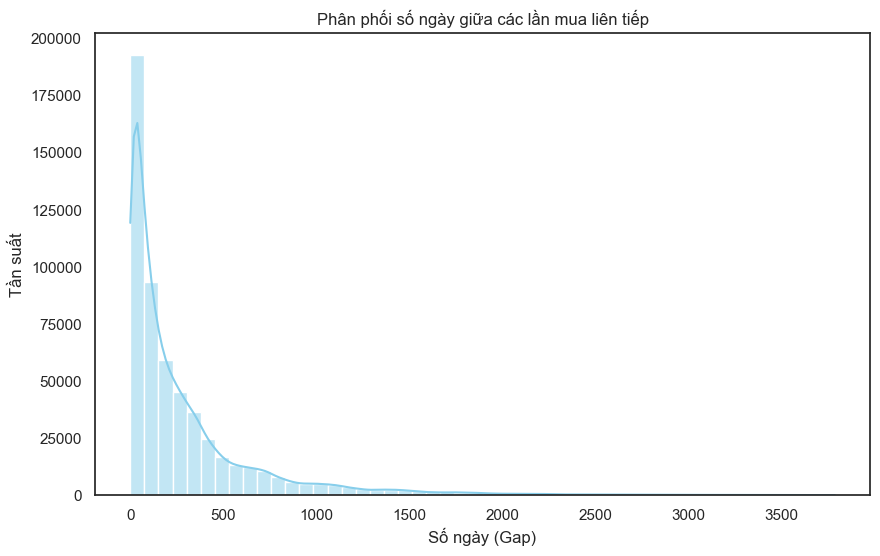

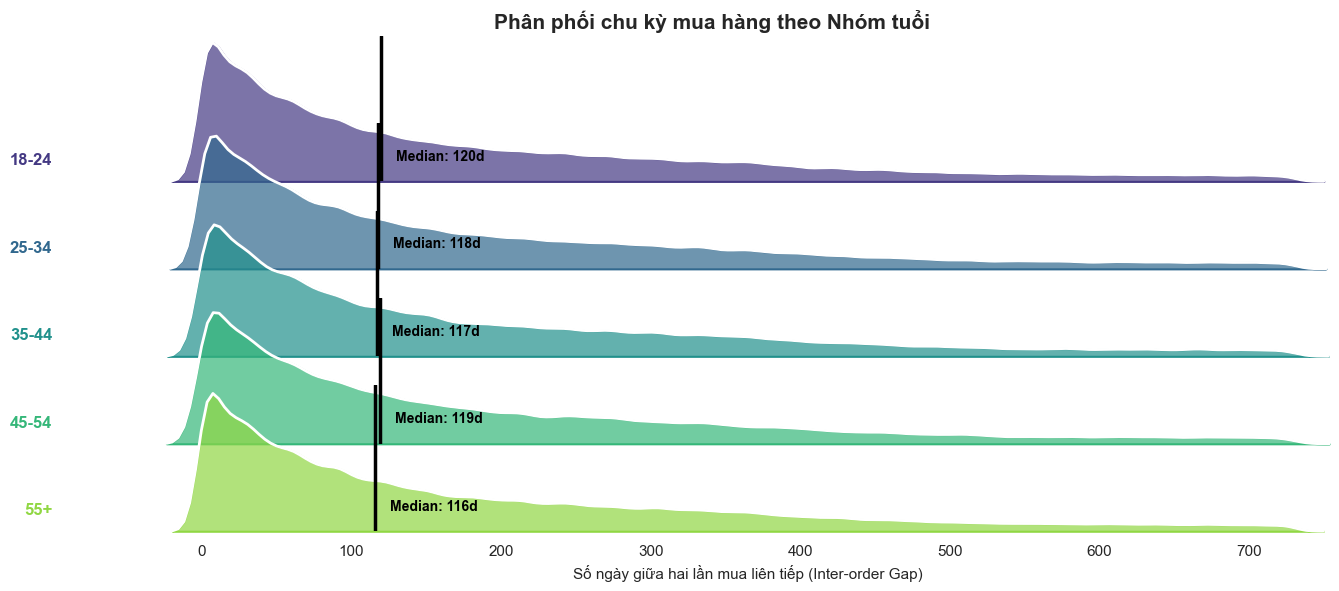

In [43]:
# --- Tiền xử lý dữ liệu Inter-order Gap ---
# Sắp xếp và tính khoảng cách ngày giữa các đơn của cùng 1 khách hàng
orders_sorted = orders.sort_values(['customer_id', 'order_date'])
orders_sorted['prev_order_date'] = orders_sorted.groupby('customer_id')['order_date'].shift(1)
orders_sorted['inter_order_gap'] = (orders_sorted['order_date'] - orders_sorted['prev_order_date']).dt.days

# --- 2.1 Histogram + KDE: Phân phối Inter-order Gap ---
plt.figure(figsize=(10, 6))
sns.histplot(orders_sorted['inter_order_gap'].dropna(), kde=True, color='skyblue', bins=50)
plt.title('Phân phối số ngày giữa các lần mua liên tiếp')
plt.xlabel('Số ngày (Gap)')
plt.ylabel('Tần suất')
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# 1. Lọc dữ liệu
df_filtered = df_ridge[df_ridge['inter_order_gap'] <= 730] 

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# 2. Khởi tạo FacetGrid
# Lấy danh sách nhóm tuổi để đổ màu chính xác
age_groups = sorted(df_filtered['age_group'].unique())
palette = sns.color_palette("viridis", len(age_groups))

g = sns.FacetGrid(df_filtered, row="age_group", hue="age_group", 
                  aspect=10, height=1.2, palette="viridis")

# 3. Vẽ KDE
g.map(sns.kdeplot, "inter_order_gap", bw_adjust=.4, clip_on=False, 
      fill=True, alpha=0.7, linewidth=1.5)
g.map(sns.kdeplot, "inter_order_gap", clip_on=False, color="white", lw=2, bw_adjust=.4)

# 4. Tinh chỉnh hiển thị
g.fig.subplots_adjust(hspace=-0.4)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)

# 5. THÊM CHÚ THÍCH (ANNOTATION) VÀ MEDIAN
for i, (ax, name) in enumerate(zip(g.axes.flat, age_groups)):
    sub_df = df_filtered[df_filtered['age_group'] == name]
    median = sub_df['inter_order_gap'].median()
    
    # Vẽ đường Median đen đậm
    ax.axvline(median, color='black', linestyle='-', linewidth=2.5)
    
    # Text Median
    ax.text(median + 10, 0.001, f'Median: {int(median)}d', 
            color='black', fontsize=10, fontweight='bold')
    
    # THÊM CHÚ THÍCH TÊN NHÓM TUỔI: 
    # Ghi trực tiếp bên trái biểu đồ với màu tương ứng
    ax.text(-100, 0.001, name, fontweight="bold", color=palette[i],
            ha="right", va="center", transform=ax.transData, fontsize=12)

plt.suptitle("Phân phối chu kỳ mua hàng theo Nhóm tuổi", y=0.98, fontsize=15, fontweight='bold')
g.set_xlabels("Số ngày giữa hai lần mua liên tiếp (Inter-order Gap)", fontsize=11)
plt.xlim(0, 730)
plt.show()